In this notebook we test out Microstructure generator classes.

In [1]:
import torch
from microstructures import CentralFiber, CentralCornerFiber, RandomBlocks

In [2]:
resolution = 96
device = "cuda"
dtype = torch.float64 

# Volumetric fractions to test
fhard_values = [0.25, 0.40, 0.50]

In [3]:
gen_central = CentralFiber(resolution=resolution)
gen_periodic = CentralCornerFiber(resolution=resolution)
gen_blocks = RandomBlocks(resolution=resolution, n_blocks=8)   # 8x8 como en RVE_geo.py

print("✅ Generators instantiated successfully")
print(f"   Resolution = {resolution}")
print(f"   Device     = {device} | dtype = {dtype}")

✅ Generators instantiated successfully
   Resolution = 96
   Device     = cuda | dtype = torch.float64



STARTING VISUAL AND VOLUME FRACTION VERIFICATION

🔹 Testing fhard = 0.25
   CentralFiber       → real fhard = 0.24523 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


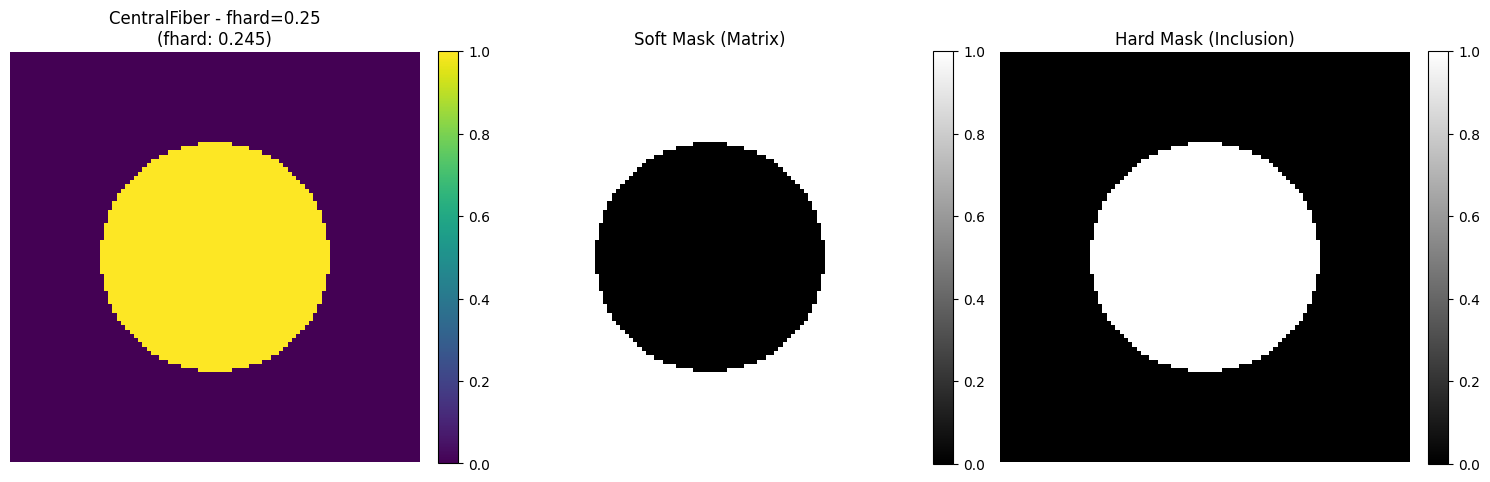

   CentralCornerFiber → real fhard = 0.25130 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


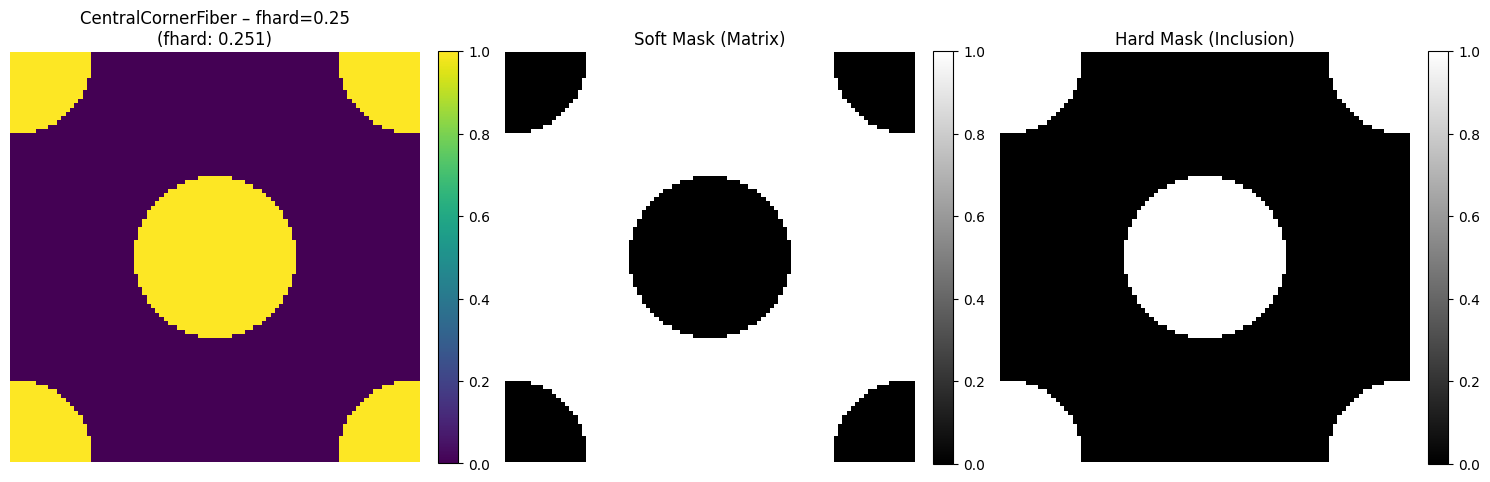

   RandomBlocks       → real fhard = 0.25000 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


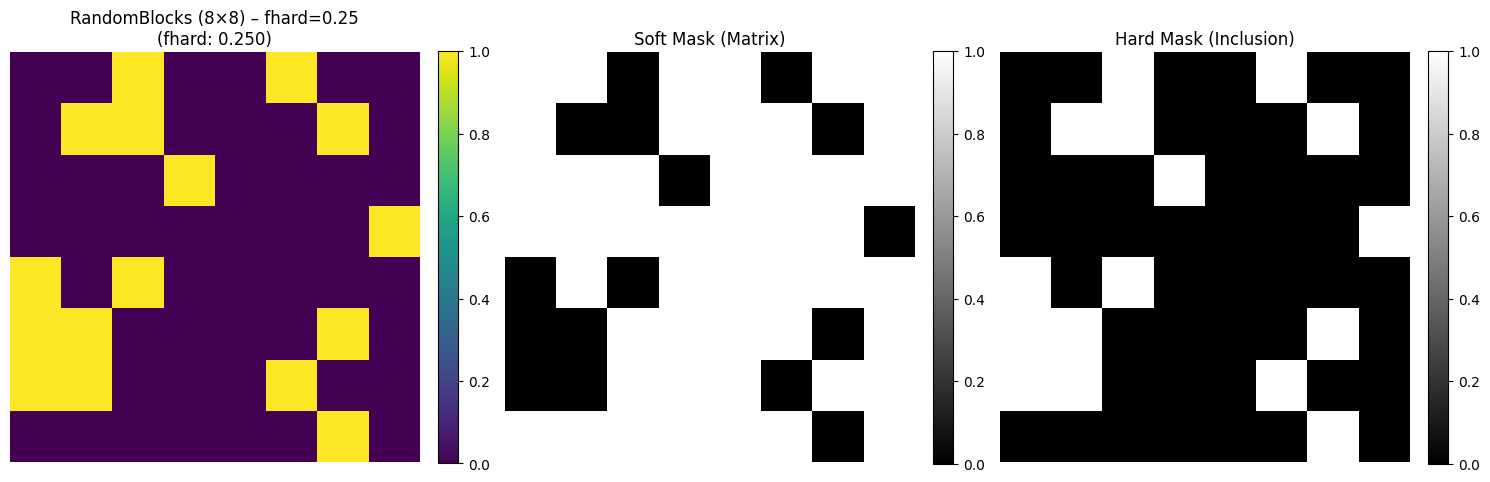


🔹 Testing fhard = 0.40
   CentralFiber       → real fhard = 0.39236 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


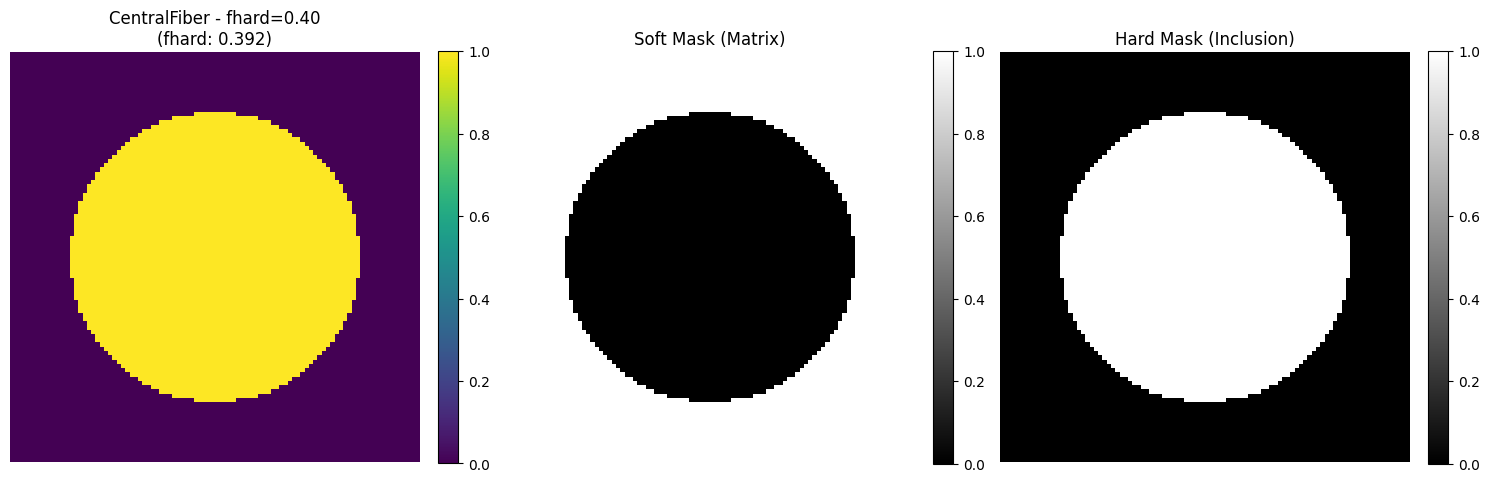

   CentralCornerFiber → real fhard = 0.40017 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


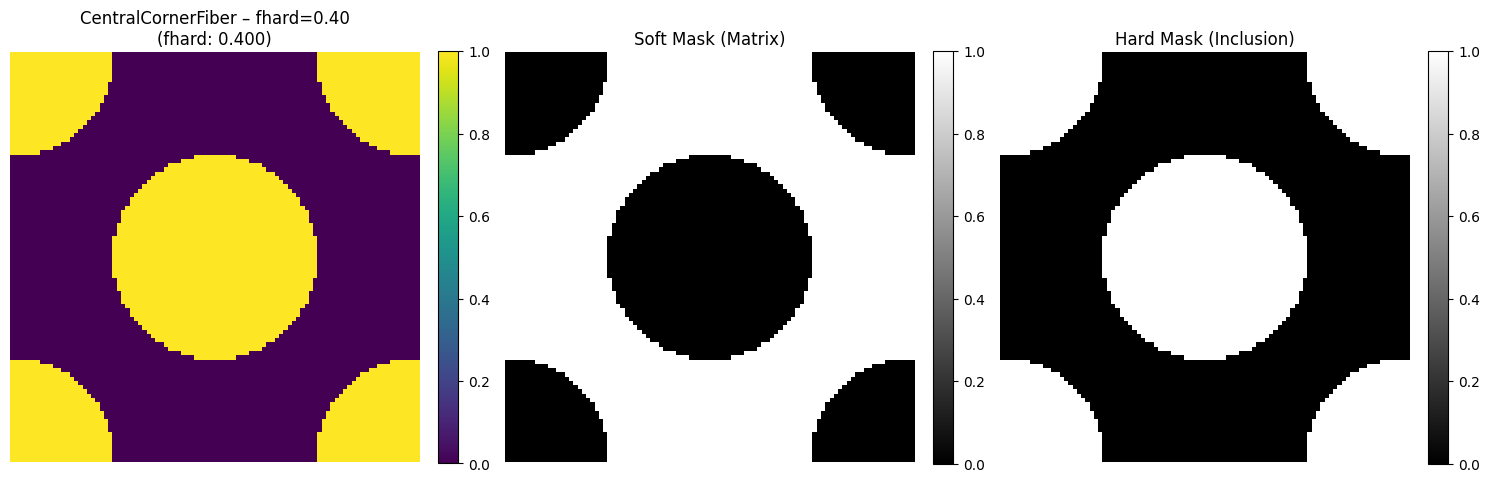

   RandomBlocks       → real fhard = 0.40625 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


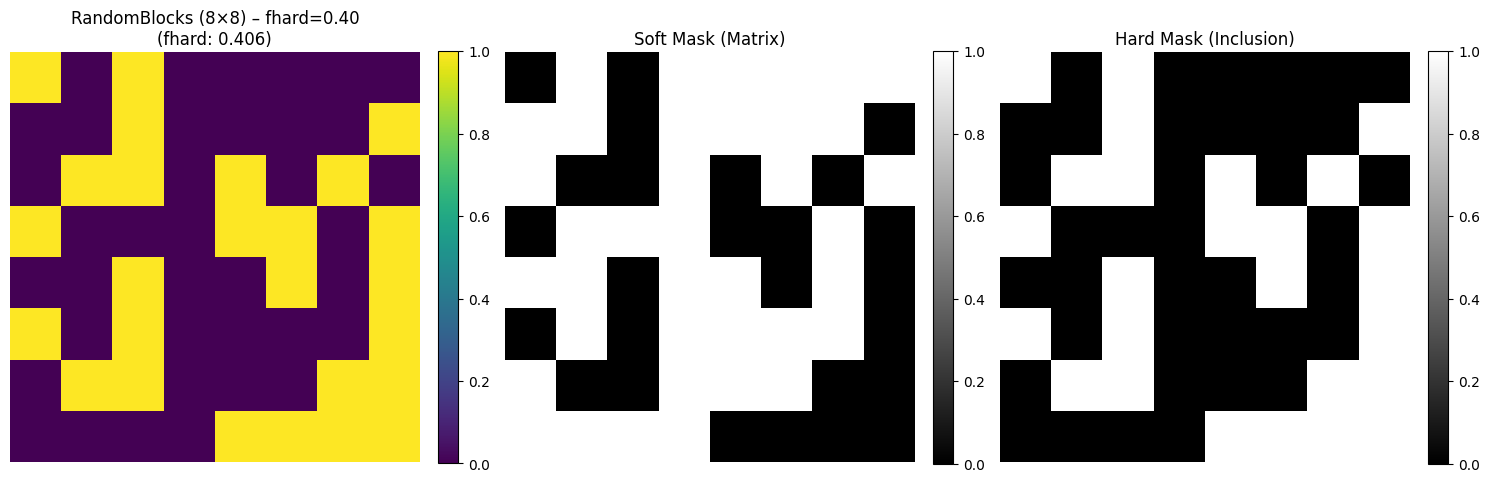


🔹 Testing fhard = 0.50
   CentralFiber       → real fhard = 0.48915 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


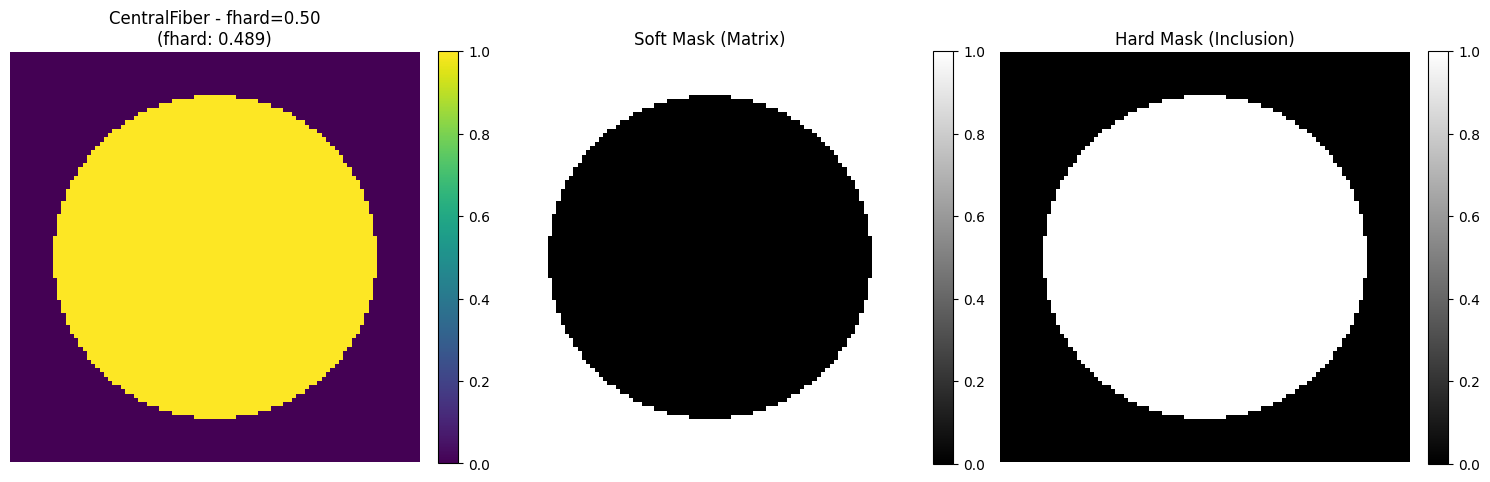

   CentralCornerFiber → real fhard = 0.50000 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


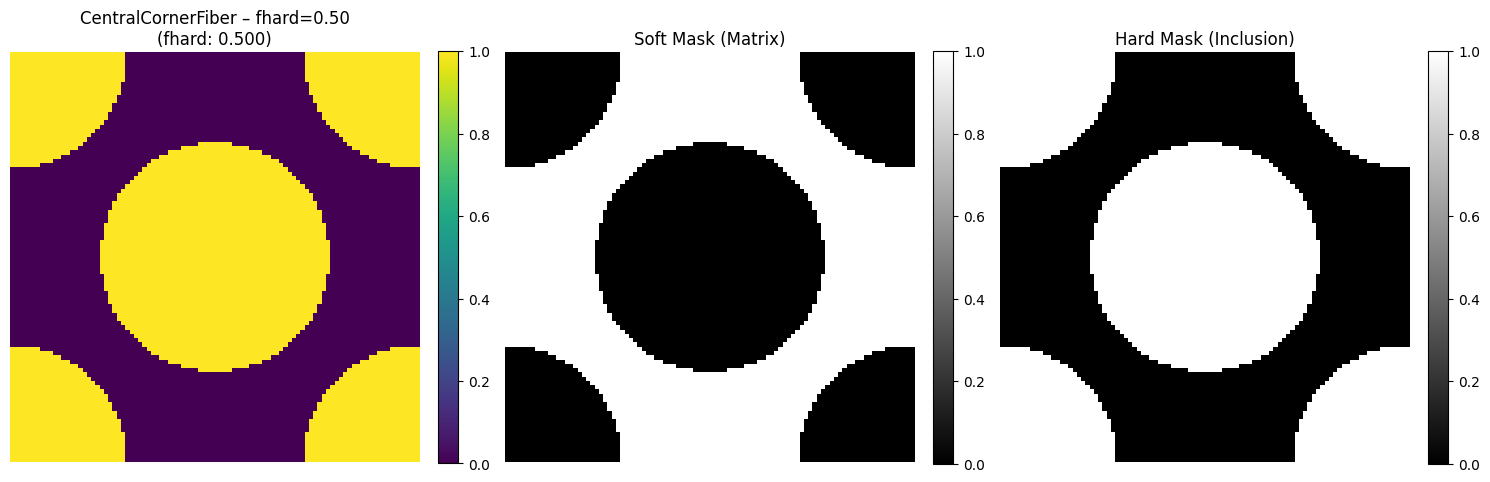

   RandomBlocks       → real fhard = 0.50000 | shapes = torch.Size([1, 96, 96]), torch.Size([96, 96])


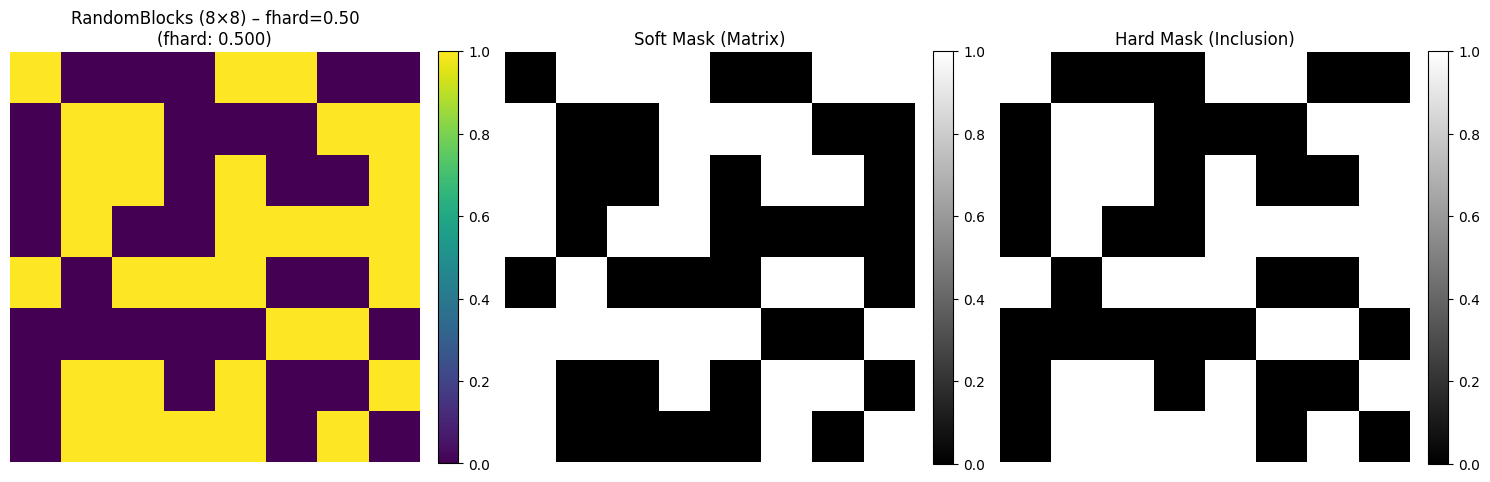


✅ Verification completed!
   • All shapes are consistent: phase=(1,96,96) | masks=(96,96)
   • Volume fraction (fhard) is respected with analytical/exact precision


In [4]:
print("\n" + "="*80)
print("STARTING VISUAL AND VOLUME FRACTION VERIFICATION")
print("="*80)

for fhard in fhard_values:
    print(f"\n🔹 Testing fhard = {fhard:.2f}")
    
    # CentralFiber
    phase_c, m_soft_c, m_hard_c = gen_central.generate(fhard, device=device, dtype=dtype)
    print(f"   CentralFiber       → real fhard = {phase_c.mean().item():.5f} | shapes = {phase_c.shape}, {m_hard_c.shape}")
    gen_central.plot(fhard, title=f"CentralFiber - fhard={fhard:.2f}")
    
    # CentralCornerFiber
    phase_p, m_soft_p, m_hard_p = gen_periodic.generate(fhard, device=device, dtype=dtype)
    print(f"   CentralCornerFiber → real fhard = {phase_p.mean().item():.5f} | shapes = {phase_p.shape}, {m_hard_p.shape}")
    gen_periodic.plot(fhard, title=f"CentralCornerFiber – fhard={fhard:.2f}")
    
    # RandomBlocks
    phase_b, m_soft_b, m_hard_b = gen_blocks.generate(fhard, device=device, dtype=dtype)
    print(f"   RandomBlocks       → real fhard = {phase_b.mean().item():.5f} | shapes = {phase_b.shape}, {m_hard_b.shape}")
    gen_blocks.plot(fhard, title=f"RandomBlocks (8×8) – fhard={fhard:.2f}")

print("\n✅ Verification completed!")
print("   • All shapes are consistent: phase=(1,96,96) | masks=(96,96)")
print("   • Volume fraction (fhard) is respected with analytical/exact precision")